In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv(r'C:\Users\keert\Downloads\1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv')

In [6]:
print(df.head())


  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
print("Rows and Columns:", df.shape)

Rows and Columns: (301, 9)


In [9]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [10]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 2


In [11]:
df = df.drop_duplicates()

In [12]:
print(df.describe())

              Year  Selling_Price  Present_Price     Kms_Driven       Owner
count   299.000000     299.000000     299.000000     299.000000  299.000000
mean   2013.615385       4.589632       7.541037   36916.752508    0.043478
std       2.896868       4.984240       8.567887   39015.170352    0.248720
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.850000       1.200000   15000.000000    0.000000
50%    2014.000000       3.510000       6.100000   32000.000000    0.000000
75%    2016.000000       6.000000       9.840000   48883.500000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [13]:
df['car_age'] = 2026 - df['Year']

In [14]:
print(df[['Year', 'car_age']].head())

   Year  car_age
0  2014       12
1  2013       13
2  2017        9
3  2011       15
4  2014       12


In [15]:
print(df.shape)
print(df.describe())

(299, 10)
              Year  Selling_Price  Present_Price     Kms_Driven       Owner  \
count   299.000000     299.000000     299.000000     299.000000  299.000000   
mean   2013.615385       4.589632       7.541037   36916.752508    0.043478   
std       2.896868       4.984240       8.567887   39015.170352    0.248720   
min    2003.000000       0.100000       0.320000     500.000000    0.000000   
25%    2012.000000       0.850000       1.200000   15000.000000    0.000000   
50%    2014.000000       3.510000       6.100000   32000.000000    0.000000   
75%    2016.000000       6.000000       9.840000   48883.500000    0.000000   
max    2018.000000      35.000000      92.600000  500000.000000    3.000000   

          car_age  
count  299.000000  
mean    12.384615  
std      2.896868  
min      8.000000  
25%     10.000000  
50%     12.000000  
75%     14.000000  
max     23.000000  


In [16]:
print(df.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
car_age          0
dtype: int64


In [17]:
df['Brand'] = df['Car_Name'].str.split().str[0]

print(df[['Car_Name', 'Brand']].head())

  Car_Name  Brand
0     ritz   ritz
1      sx4    sx4
2     ciaz   ciaz
3  wagon r  wagon
4    swift  swift


In [18]:
brand_count = df['Brand'].value_counts().head(10)

print(brand_count)

Brand
city        26
Bajaj       25
corolla     17
Royal       17
Honda       17
Hero        15
verna       14
etios       11
fortuner    10
brio        10
Name: count, dtype: int64


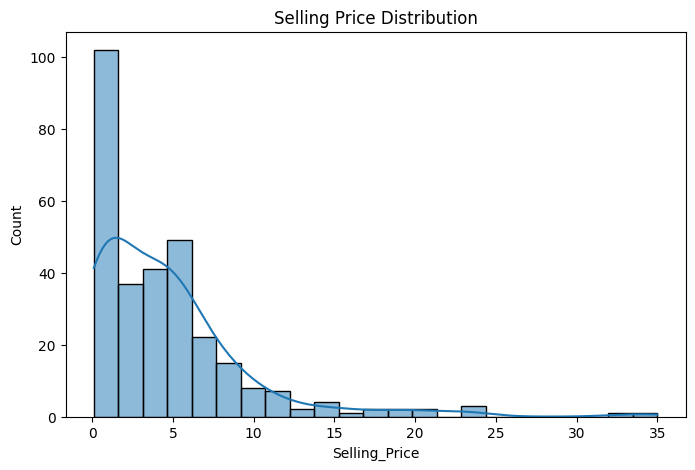

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['Selling_Price'], kde=True)

plt.title("Selling Price Distribution")
plt.show()

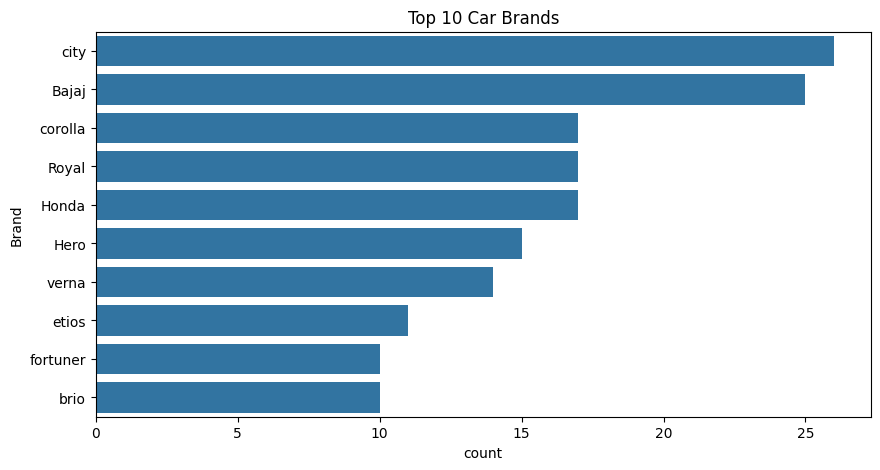

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(
    y='Brand',
    data=df,
    order=df['Brand'].value_counts().head(10).index
)
plt.title("Top 10 Car Brands")
plt.show()

In [21]:
print(df['Fuel_Type'].value_counts())

Fuel_Type
Petrol    239
Diesel     58
CNG         2
Name: count, dtype: int64


In [ ]:
sns.countplot(x='Fuel_Type', data=df)
plt.title("Fuel Type Distribution")
plt.show()

In [23]:
print(df['Transmission'].value_counts())

Transmission
Manual       260
Automatic     39
Name: count, dtype: int64


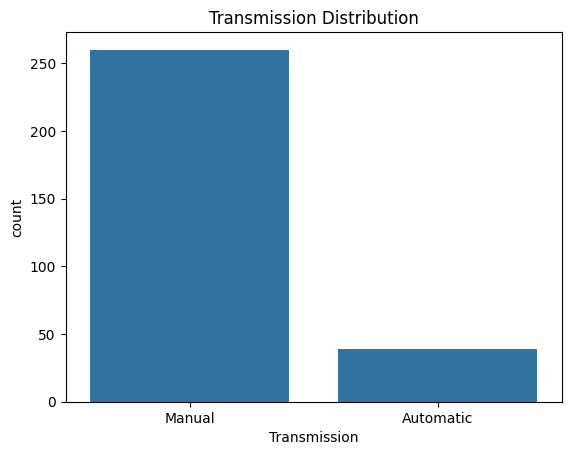

In [24]:
sns.countplot(x='Transmission', data=df)
plt.title("Transmission Distribution")
plt.show()

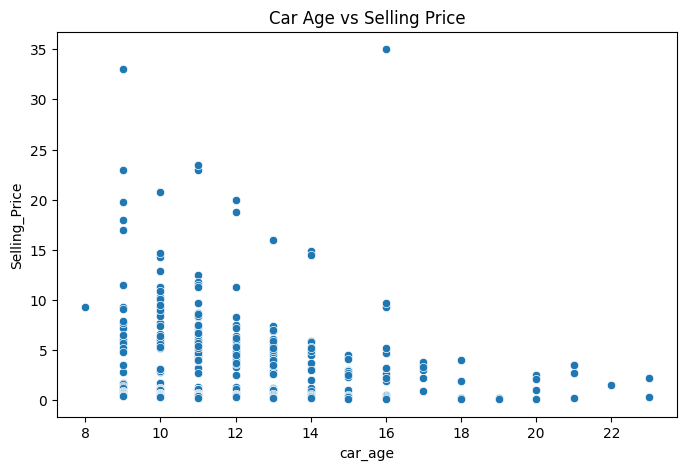

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='car_age',
    y='Selling_Price',
    data=df
)
plt.title("Car Age vs Selling Price")
plt.show()

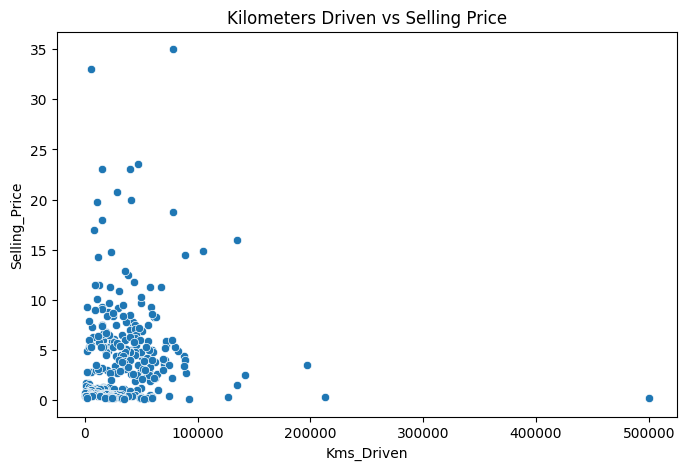

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Kms_Driven',
    y='Selling_Price',
    data=df
)
plt.title("Kilometers Driven vs Selling Price")
plt.show()

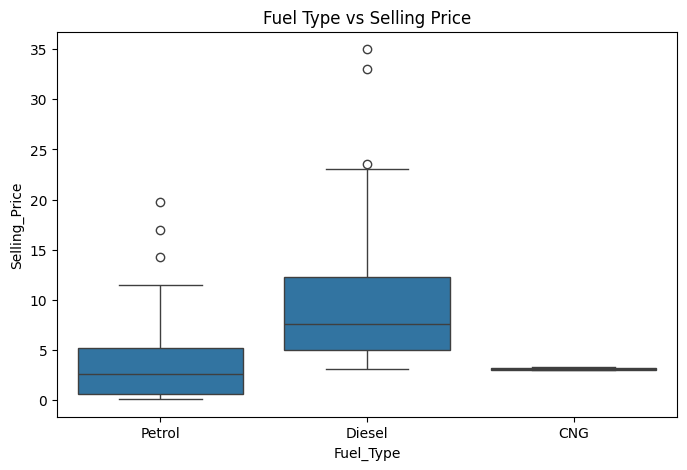

In [27]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Fuel_Type',
    y='Selling_Price',
    data=df
)
plt.title("Fuel Type vs Selling Price")
plt.show()

In [28]:
numeric_df = df.select_dtypes(include='number')

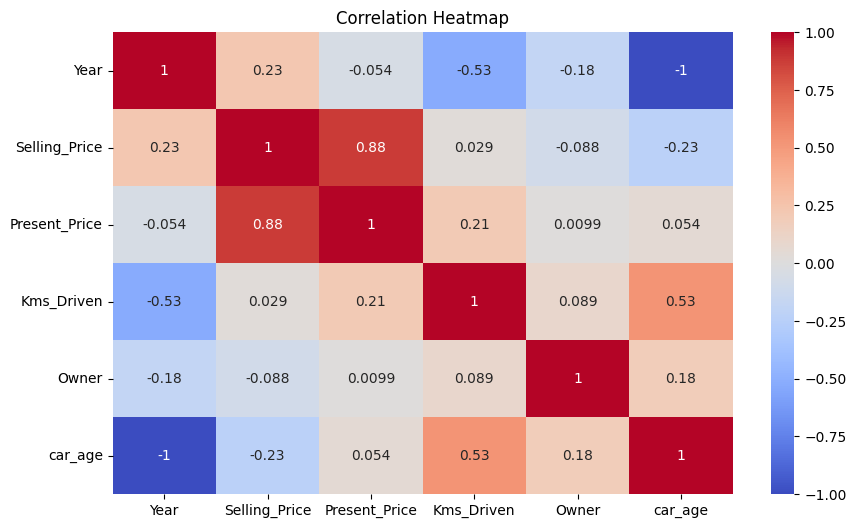

In [29]:
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [30]:
brand_price = (
    df.groupby('Brand')['Selling_Price']
      .mean()
      .sort_values(ascending=False)
)

print(brand_price)

Brand
land        35.000000
fortuner    18.254000
innova      12.777778
creta       11.800000
elantra     11.600000
vitara       9.250000
ciaz         7.472222
city         7.419231
corolla      6.848824
ertiga       6.580000
s            6.500000
verna        6.107857
baleno       5.850000
jazz         5.828571
xcent        4.966667
grand        4.943750
ignis        4.900000
i20          4.766667
brio         4.745000
swift        4.540000
dzire        4.475000
amaze        4.221429
etios        4.204545
sx4          3.158333
i10          3.060000
eon          2.900000
ritz         2.862500
alto         2.616667
wagon        2.512500
camry        2.500000
UM           1.700000
Hyosung      1.350000
KTM          1.337500
omni         1.250000
Mahindra     1.150000
Royal        1.144706
Yamaha       0.582500
Bajaj        0.528000
TVS          0.462500
Honda        0.438235
Hero         0.362000
800          0.350000
Activa       0.340000
Suzuki       0.250000
Name: Selling_Price, dtype

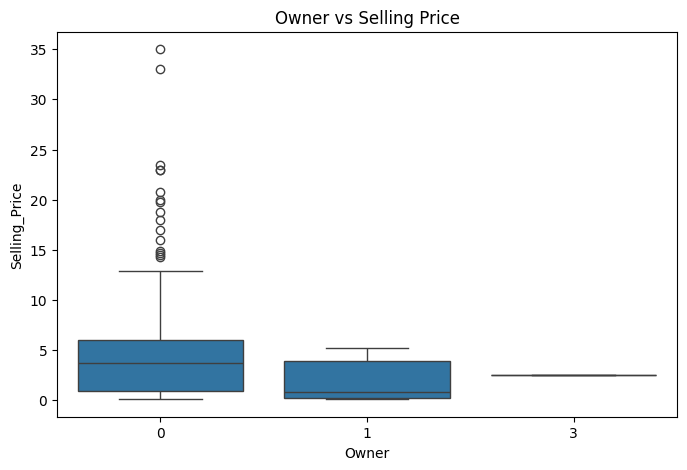

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Owner',
    y='Selling_Price',
    data=df
)

plt.title("Owner vs Selling Price")
plt.show()